
<font color="#CA3532"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Pruebas de modelos</h2></font> 

#### David Alejandro Pedroza De Jesús

#   Librerias usadas

In [11]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix,classification_report, roc_auc_score, roc_curve
import seaborn as sns
import torch
from ultralytics import YOLO

#   Carga de los CSVs

Cargamos y modificamos como en el notebook anterior; el primer paso será cargarlos.

In [12]:
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")

In [13]:
def muestras_data_set(df,n, seed, use_seed = False):
    especies = pd.unique(df.label)
    df_final = pd.DataFrame(columns=df.columns)
    for especie in especies:
        df_fil = df[df.label == especie]
        if use_seed:
            df_fil = df_fil.sample(n=n, random_state=seed)
        else:
            df_fil = df_fil.sample(n=n)
        df_final = pd.concat([df_final, df_fil], ignore_index=True)
    return df_final

Y ahora aplicamos un inner join para filtrar las especies que solo se encuentran en Valencia, además esto añadirá una columna para saber cuales son comestibles y cuales no.

In [14]:
test = pd.merge(info_especies, rutas_test, on='label', how='inner')
test = muestras_data_set(test, n = 35, seed= 666, use_seed= True)

Arregamos las rutas para que sean correctas.

In [15]:
def ArreglarLasRutas(df):
    rutas_nuevas = []
    for path in df.image_path:
        path = path.lstrip("/")
        rutas_nuevas.append(path)
    df.image_path = rutas_nuevas

ArreglarLasRutas(test)


Ahora cargamos las imagenes usando lo obtenido en el chunk anterior.

In [16]:

val_datagen = ImageDataGenerator(rescale=1./255)

test_generator = val_datagen.flow_from_dataframe(
    dataframe=test,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)


Found 1995 validated image filenames belonging to 57 classes.


#   mobielnet


In [17]:
eff = tf.keras.models.load_model(r"Modelos\mov1.keras")

-   Obtendremos las predicciones para el conjunto train.

In [18]:
y_pre = eff.predict(test_generator)
y_pred_class = np.argmax(y_pre, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 581ms/step


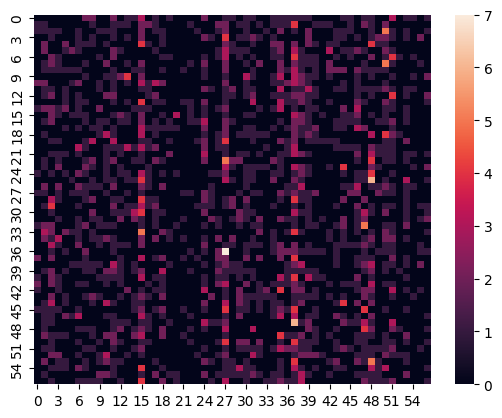

In [19]:
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_class)
target_names = list(test_generator.class_indices.keys())
sns.heatmap(cm)
plt.show()


In [20]:
target_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred_class, target_names=target_names))

                             precision    recall  f1-score   support

          Agaricus augustus       0.00      0.00      0.00        35
      Agaricus xanthodermus       0.02      0.03      0.03        35
            Amanita citrina       0.02      0.03      0.02        35
           Amanita muscaria       0.00      0.00      0.00        35
         Amanita pantherina       0.09      0.06      0.07        35
         Amanita phalloides       0.20      0.06      0.09        35
          Amanita rubescens       0.00      0.00      0.00        35
          Armillaria mellea       0.03      0.03      0.03        35
       Armillaria tabescens       0.00      0.00      0.00        35
         Bjerkandera adusta       0.00      0.00      0.00        35
         Bolbitius titubans       0.00      0.00      0.00        35
             Boletus edulis       0.02      0.03      0.02        35
           Calocera viscosa       0.00      0.00      0.00        35
      Cantharellus cibarius      

#   efficientnet 
Aquí usamos una versión mejorada del anterior

In [21]:

val_datagen = ImageDataGenerator(rescale=1./255)

test_generator = val_datagen.flow_from_dataframe(
    dataframe=test,
    x_col="image_path",
    y_col="label",
    target_size=(260, 260),
    batch_size=32,
    class_mode="categorical"
)

Found 1995 validated image filenames belonging to 57 classes.


In [22]:
eff2 = tf.keras.models.load_model("Modelos/effV2L_ver_2.keras")

In [23]:
y_pre = eff2.predict(test_generator)
y_pred_class = np.argmax(y_pre, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1341s 21s/step


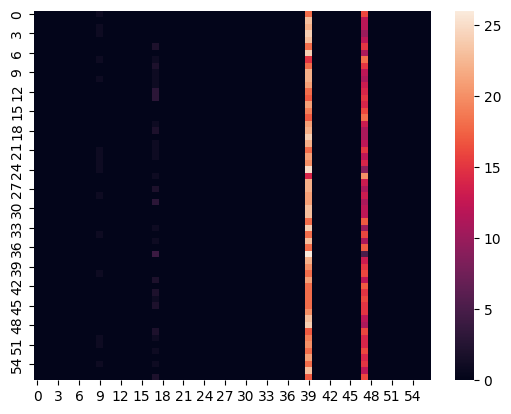

In [24]:
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_class)
target_names = list(test_generator.class_indices.keys())
sns.heatmap(cm)
plt.show()

In [25]:
target_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred_class, target_names=target_names))

                             precision    recall  f1-score   support

          Agaricus augustus       0.00      0.00      0.00        35
      Agaricus xanthodermus       0.00      0.00      0.00        35
            Amanita citrina       0.00      0.00      0.00        35
           Amanita muscaria       0.00      0.00      0.00        35
         Amanita pantherina       0.00      0.00      0.00        35
         Amanita phalloides       0.00      0.00      0.00        35
          Amanita rubescens       0.00      0.00      0.00        35
          Armillaria mellea       0.00      0.00      0.00        35
       Armillaria tabescens       0.00      0.00      0.00        35
         Bjerkandera adusta       0.00      0.00      0.00        35
         Bolbitius titubans       0.00      0.00      0.00        35
             Boletus edulis       0.00      0.00      0.00        35
           Calocera viscosa       0.00      0.00      0.00        35
      Cantharellus cibarius      

c:\Users\David\miniconda3\envs\TFG\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\David\miniconda3\envs\TFG\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\David\miniconda3\envs\TFG\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

#   Yolo.
Aquí probaremos el modelo YOLO y calcularemos las metricas necesarias.

In [26]:
Model = YOLO("Modelos/runstf/classify/train/weights/best.pt")

In [27]:
def get_prediction(results,labels):
    results_ls = results[0]
    especie_lab_pred = labels[results_ls.probs.top1]
    especie_pred = results_ls.probs.top1
    prob = results_ls.probs.top1conf.cpu().numpy()
    return especie_lab_pred,especie_pred,prob

In [28]:
labels = test.label.unique()
y_true = []
y_pred = []
for registro,real_name in zip(test.image_path,test.label):
    img = cv2.imread(registro)
    results = Model(img)
    results_ls = results[0]
    y_true.append(int(np.where(labels == real_name)[0][0]))
    y_pred.append(get_prediction(results,labels)[1])



0: 256x256 Agaricus augustus 0.42, Amanita citrina 0.24, Leucoagaricus americanus 0.20, Amanita muscaria 0.05, Chlorophyllum molybdites 0.03, 99.5ms
Speed: 43.3ms preprocess, 99.5ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Agaricus augustus 1.00, Agaricus xanthodermus 0.00, Macrolepiota procera 0.00, Chlorophyllum molybdites 0.00, Leucoagaricus americanus 0.00, 21.5ms
Speed: 13.4ms preprocess, 21.5ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Agaricus xanthodermus 0.62, Agaricus augustus 0.15, Chlorophyllum molybdites 0.09, Panellus stipticus 0.08, Suillus luteus 0.05, 22.2ms
Speed: 12.5ms preprocess, 22.2ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)

0: 256x256 Agaricus augustus 1.00, Leucoagaricus americanus 0.00, Tricholomopsis rutilans 0.00, Agaricus xanthodermus 0.00, Amanita rubescens 0.00, 23.2ms
Speed: 13.1ms preprocess, 23.2ms inference, 0.1ms postprocess per image at shape (1, 3, 256,

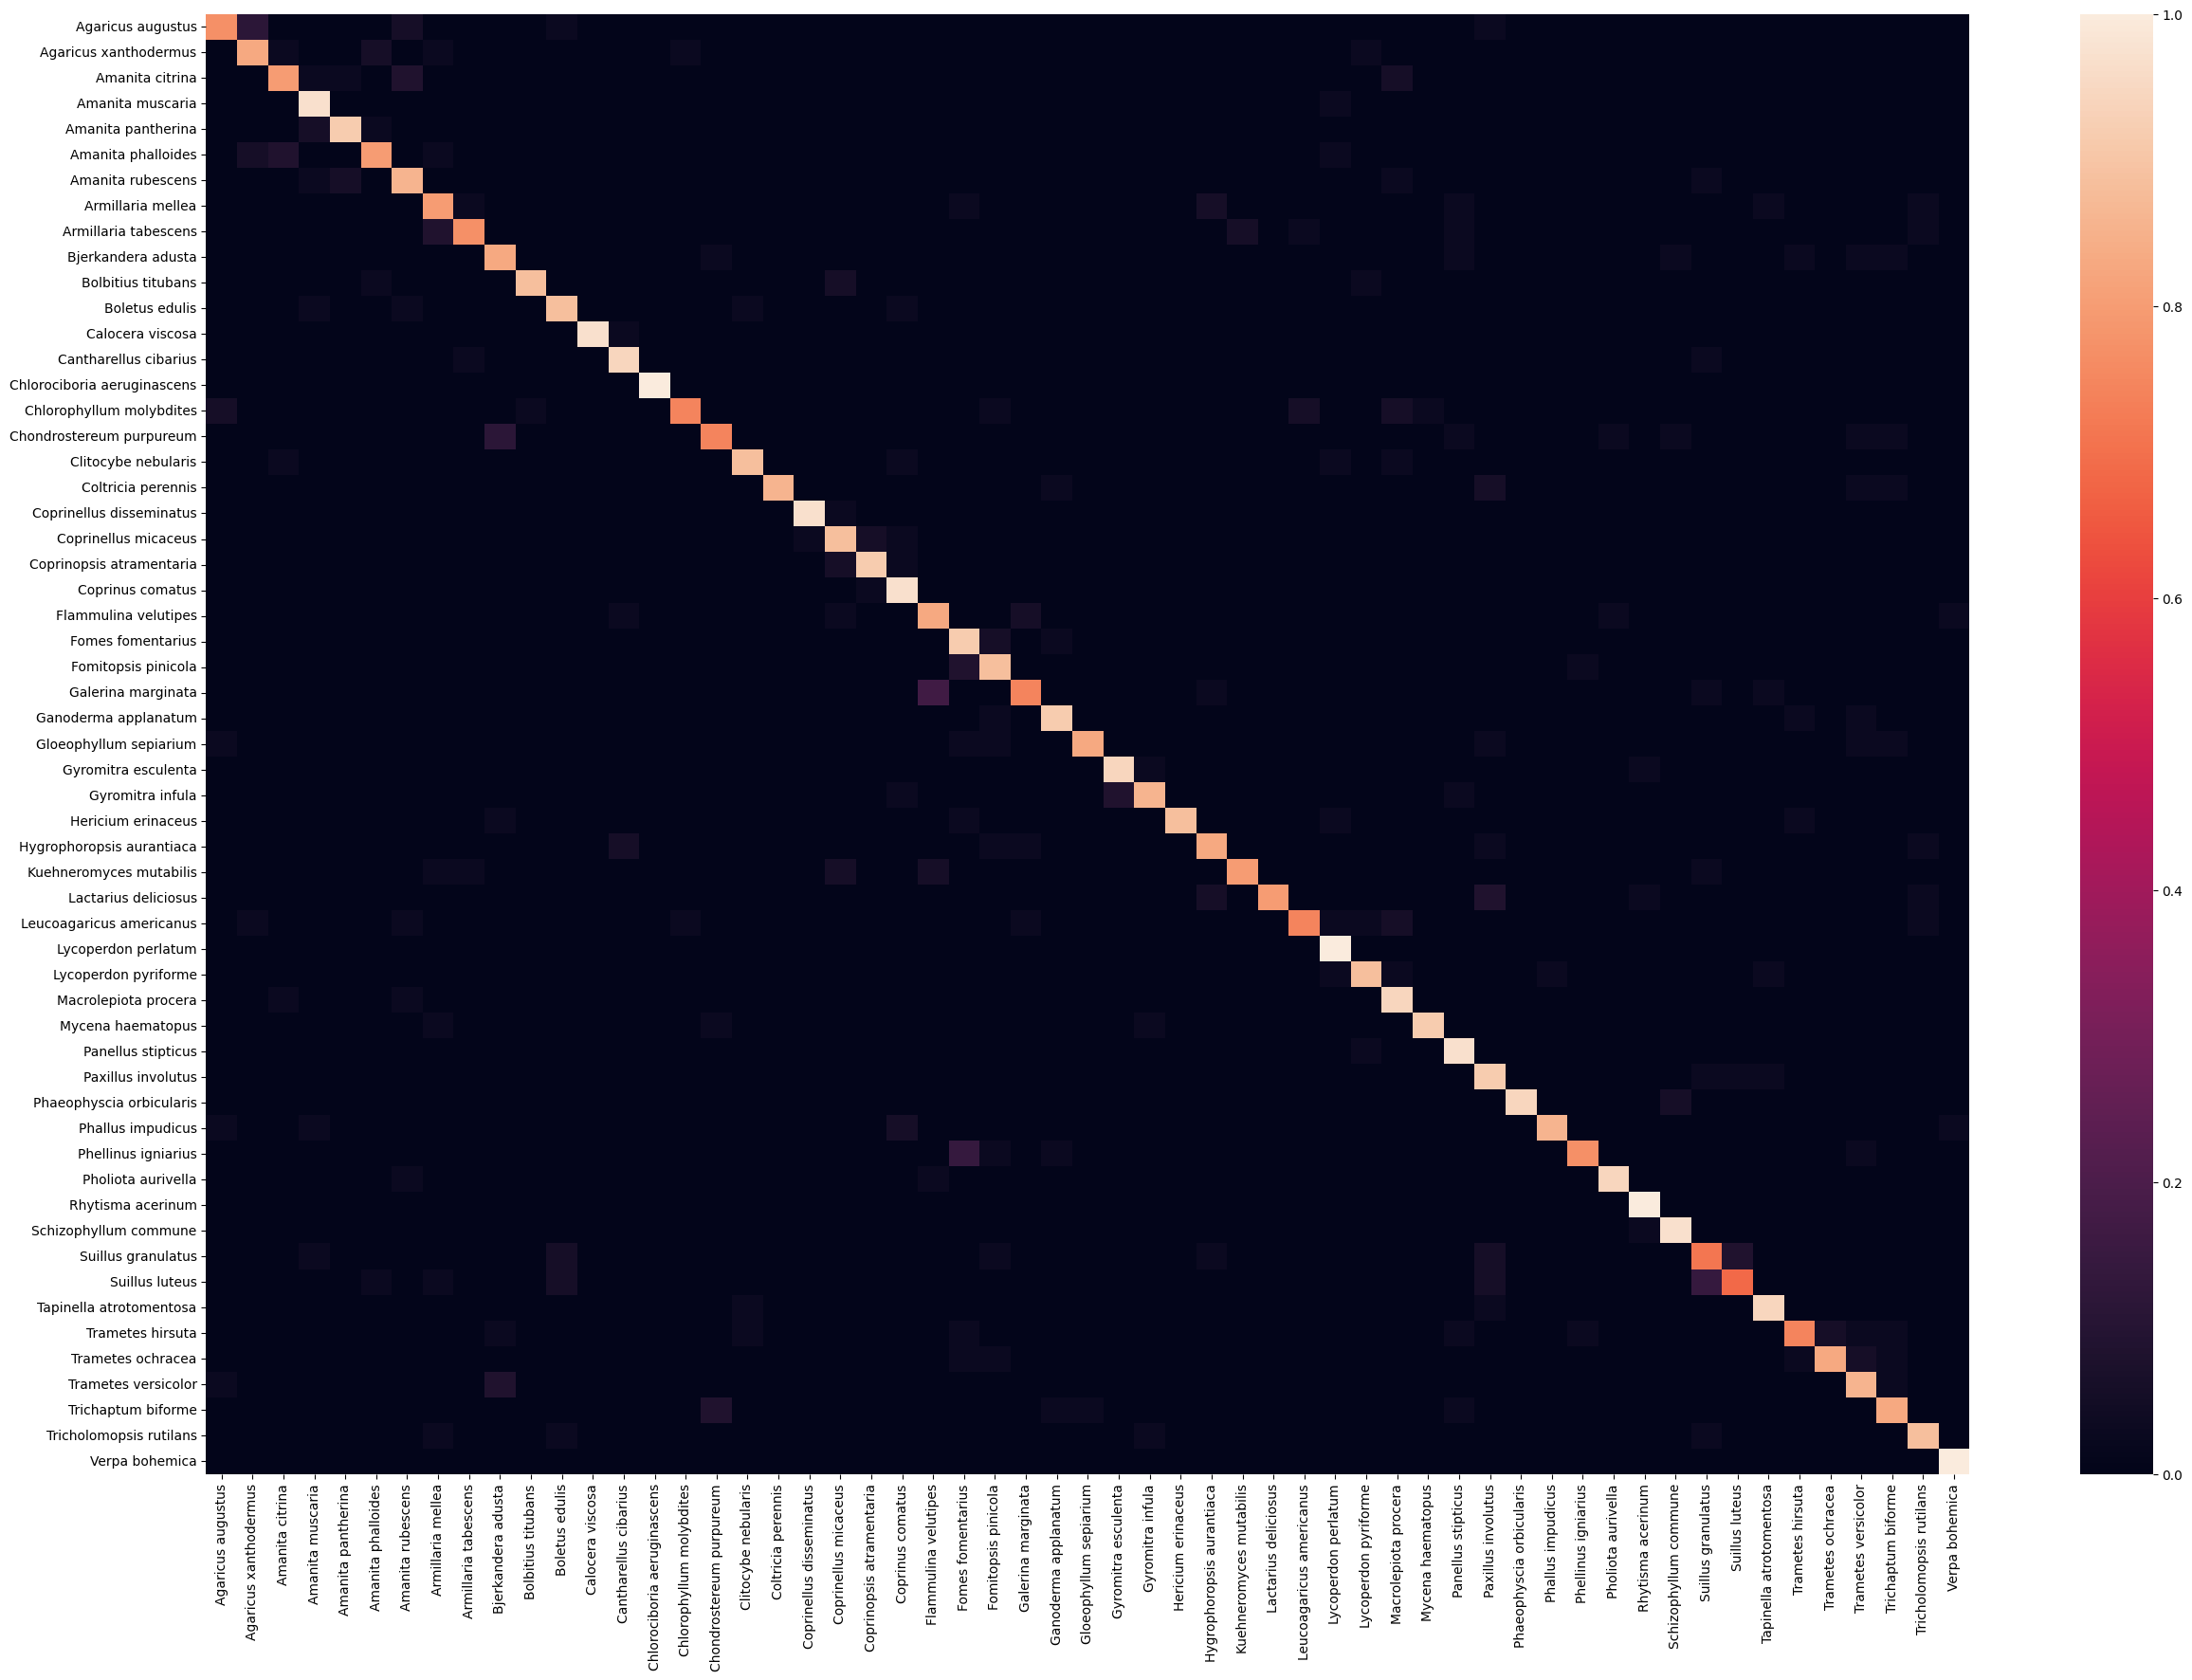

In [29]:
cm = confusion_matrix(y_true, y_pred, normalize= "true")

plt.subplots(figsize=(30,20))
sns.heatmap(cm,xticklabels= labels, yticklabels= labels)
plt.show()

In [30]:
print(classification_report(y_true, y_pred, target_names=labels))

                             precision    recall  f1-score   support

          Agaricus augustus       0.84      0.77      0.81        35
      Agaricus xanthodermus       0.81      0.83      0.82        35
            Amanita citrina       0.82      0.80      0.81        35
           Amanita muscaria       0.83      0.97      0.89        35
         Amanita pantherina       0.91      0.91      0.91        35
         Amanita phalloides       0.85      0.80      0.82        35
          Amanita rubescens       0.77      0.86      0.81        35
          Armillaria mellea       0.76      0.80      0.78        35
       Armillaria tabescens       0.90      0.77      0.83        35
         Bjerkandera adusta       0.76      0.83      0.79        35
         Bolbitius titubans       0.97      0.89      0.93        35
             Boletus edulis       0.84      0.89      0.86        35
           Calocera viscosa       1.00      0.97      0.99        35
      Cantharellus cibarius      

##  Predicciones para saber si son cometibles. 

In [31]:
name_true = pd.DataFrame({"label":labels[y_true]})
name_pred = pd.DataFrame({"label":labels[y_pred]})

eat_true_df = pd.merge(name_true, info_especies, on='label', how='inner')
eat_pred_df = pd.merge(name_pred, info_especies, on='label', how='inner')

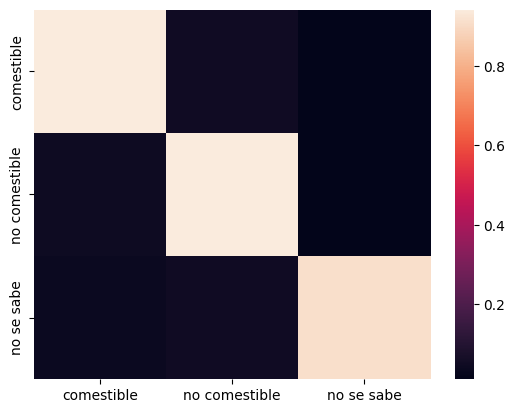

In [32]:
labs = info_especies.Info.unique()
cm = confusion_matrix(eat_true_df.Info, eat_pred_df.Info, normalize = "true")


sns.heatmap(cm,xticklabels= labs, yticklabels= labs)
plt.show()

In [33]:
print(cm)

[[    0.94037    0.048447     0.01118]
 [   0.045714     0.94171    0.012571]
 [   0.038095    0.050794     0.91111]]


In [34]:
print(classification_report(eat_true_df.Info, eat_pred_df.Info))

               precision    recall  f1-score   support

   comestible       0.94      0.94      0.94       805
no comestible       0.94      0.94      0.94       875
   no se sabe       0.93      0.91      0.92       315

     accuracy                           0.94      1995
    macro avg       0.94      0.93      0.93      1995
 weighted avg       0.94      0.94      0.94      1995

